<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:39: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2622/924558275.py:39: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title(f"Mapeo Adaptativo ($\lambda_6$ = {l6})")


=== RESUMEN DE LA INTELIGENCIA ADAPTATIVA (ITERACIÓN 4) ===


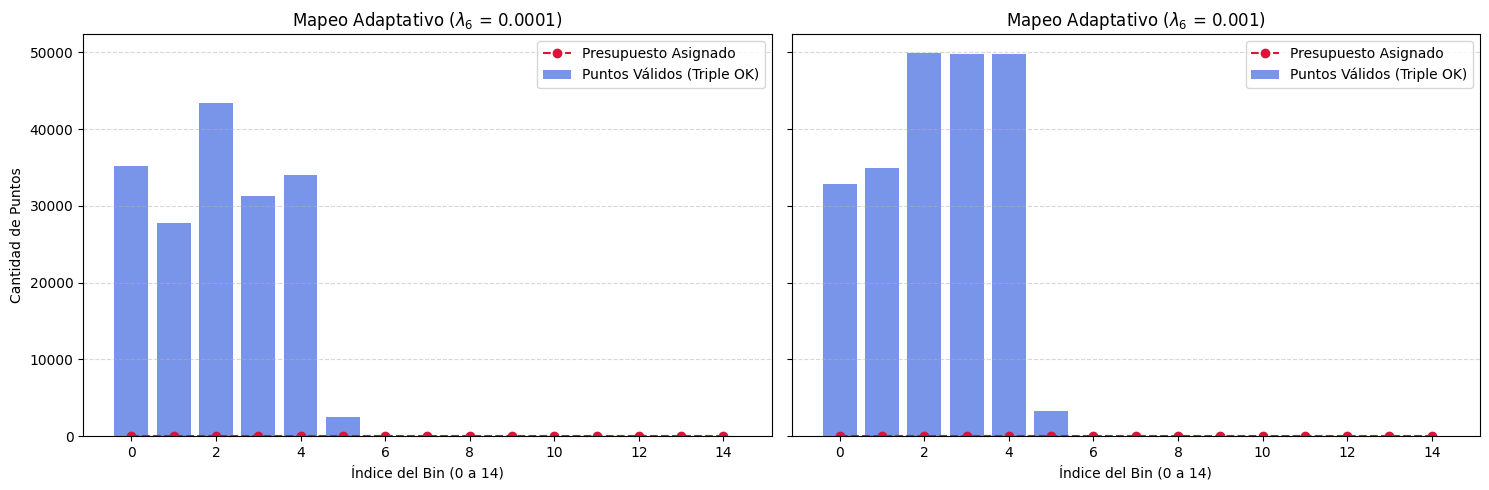


=== CARGANDO DATOS FÍSICOS DESDE EL DATA LAKE ===


/tmp/ipykernel_2622/924558275.py:63: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(df_list, ignore_index=True)


Total de puntos escaneados: 4,269,300
Puntos estrictamente válidos (Triple OK): 1,454,740
Eficiencia Global: 34.07%



/home/fabi/higgs_env_py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


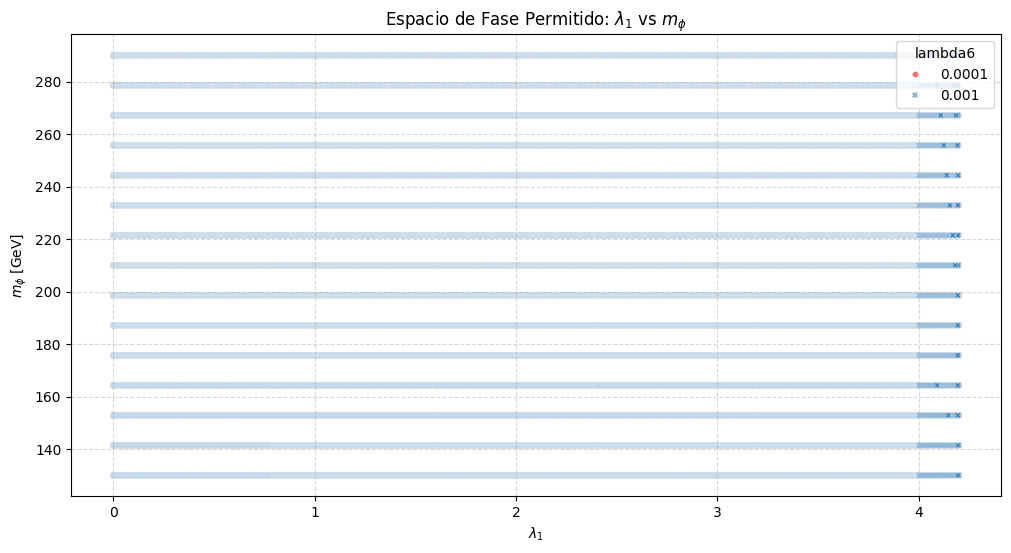

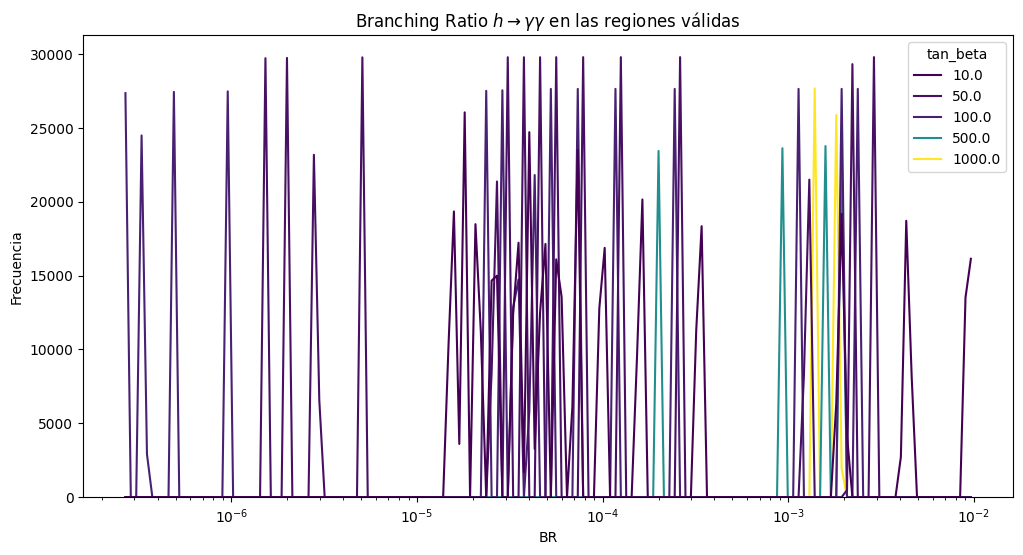

In [1]:
import pandas as pd
import json
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CONFIGURACIÓN DE RUTAS ---
CHECKPOINT_DIR = "/mnt/c/Users/Asus/cern_db/checkpoints/run_masivo_l6_low"
DATA_LAKE_DIR = "/mnt/c/Users/Asus/cern_db/dihiggs_lake/campaign=run_masivo_l6_low"
LAMBDA6_VALS = ["0.0001", "0.001"]

# --- 2. ANÁLISIS DEL EXPLORADOR (ESTADO ADAPTATIVO) ---
print("=== RESUMEN DE LA INTELIGENCIA ADAPTATIVA (ITERACIÓN 4) ===")
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for i, l6 in enumerate(LAMBDA6_VALS):
    state_file = os.path.join(CHECKPOINT_DIR, f"l6_{l6}", "iter_0004", "adaptive_state.json")
    if not os.path.exists(state_file):
        continue
        
    with open(state_file, 'r') as f:
        state = json.load(f)
    
    # Extraer los Triple-OK por bin en la última iteración
    bins = []
    triple_oks = []
    budgets = []
    
    for prop in state.get('proposals', []):
        bins.append(prop['bin_index'])
        triple_oks.append(prop['triple_ok_total'])
        budgets.append(prop['n_lam1'])
    
    ax = axes[i]
    ax.bar(bins, triple_oks, color='royalblue', alpha=0.7, label='Puntos Válidos (Triple OK)')
    ax.plot(bins, budgets, color='crimson', marker='o', linestyle='--', label='Presupuesto Asignado')
    ax.set_title(f"Mapeo Adaptativo ($\lambda_6$ = {l6})")
    ax.set_xlabel("Índice del Bin (0 a 14)")
    if i == 0: ax.set_ylabel("Cantidad de Puntos")
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# --- 3. EXTRACCIÓN Y EDA DE LOS DATOS FÍSICOS (CSVs) ---
print("\n=== CARGANDO DATOS FÍSICOS DESDE EL DATA LAKE ===")
all_csvs = glob.glob(os.path.join(DATA_LAKE_DIR, "**/*.csv"), recursive=True)

df_list = []
cols = ['m_phi', 'lam1', 'tan_beta', 'lambda6', 'positivity_ok', 'unitarity_ok', 'perturbativity_ok', 'br_gaga', 'total_width']

for f in all_csvs:
    try:
        # Cargar optimizado
        temp_df = pd.read_csv(f, usecols=cols)
        df_list.append(temp_df)
    except Exception as e:
        pass

df = pd.concat(df_list, ignore_index=True)

# Filtro Triple-OK
df['is_valid'] = (df['positivity_ok'] == 1) & (df['unitarity_ok'] == 1) & (df['perturbativity_ok'] == 1)
df_valid = df[df['is_valid']].copy()

print(f"Total de puntos escaneados: {len(df):,}")
print(f"Puntos estrictamente válidos (Triple OK): {len(df_valid):,}")
print(f"Eficiencia Global: {len(df_valid)/len(df)*100:.2f}%\n")

# --- 4. GRAFICACIÓN FÍSICA ---
# Gráfico A: Espacio de Fase Permitido (lam1 vs m_phi)
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_valid, x='lam1', y='m_phi', hue='lambda6', style='lambda6', palette='Set1', alpha=0.6, s=20)
plt.title(r"Espacio de Fase Permitido: $\lambda_1$ vs $m_\phi$")
plt.xlabel(r"$\lambda_1$")
plt.ylabel(r"$m_\phi$ [GeV]")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Gráfico B: Branching Ratio a Fotones por tan(beta)
plt.figure(figsize=(12, 6))
# Filtramos tan_beta extremos si oscurecen el gráfico
valid_low_tb = df_valid[df_valid['tan_beta'] <= 1000]
sns.histplot(data=valid_low_tb, x='br_gaga', hue='tan_beta', palette='viridis', log_scale=(True, False), element="poly", fill=False)
plt.title(r"Branching Ratio $h \to \gamma\gamma$ en las regiones válidas")
plt.xlabel("BR")
plt.ylabel("Frecuencia")
plt.show()